# STPLS3D End-to-End Pipeline

This notebook orchestrates the full workflow:
1. PLY -> LAS (stretch + tiling + reports)
2. LAS tiles -> tensors + PNG (features/RGB/masks)
3. Training
4. Evaluation on val/test
5. Quick visual checks and metric plots

It calls existing project scripts via subprocess to keep one source of truth.

In [1]:
!pip install segmentation-models-pytorch
!pip install laspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.3 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import sys

RUN_ENV = "colab"  # "local" or "colab"

if RUN_ENV == "local":
    PROJECT_ROOT = Path(r"c:\Users\alexe\VSCprojects\lidar-visual-interface")
else:
    PROJECT_ROOT = Path("/content/lidar-visual-interface")  # или ваш путь в Drive

print("PROJECT_ROOT =", PROJECT_ROOT)
print("PYTHON      =", sys.executable)

PROJECT_ROOT = /content/lidar-visual-interface
PYTHON      = /usr/bin/python3


In [2]:
# -------- Configuration --------
CFG = {
    # Input PLY directories (set these if you run PLY->LAS stage)
    'ply_train_dir': PROJECT_ROOT / 'data' / 'stpls3d_ply' / 'train',
    'ply_val_dir': PROJECT_ROOT / 'data' / 'stpls3d_ply' / 'val',
    'ply_test_dir': PROJECT_ROOT / 'data' / 'stpls3d_ply' / 'test',

    # Prepared LAS directories
    'prepared_las_root': PROJECT_ROOT / 'data' / 'stpls3d_prepared',

    # Ready image/tensor datasets
    'ready_root': PROJECT_ROOT / 'data' / 'stpls3d_ready',

    # Training artifacts
    'checkpoint_dir': PROJECT_ROOT / 'checkpoints_notebook',
    'eval_val_dir': PROJECT_ROOT / 'eval_notebook_val',
    'eval_test_dir': PROJECT_ROOT / 'eval_notebook_test',

    # Pipeline params
    'tile_size': 250,
    'target_points_per_tile': 500_000,
    'seed': 42,
    'num_points': 40_000,
    'grid_size': 512,
    'k_nn': 4,
    'knn_eps': 0.1,
    'knn_workers': -1,

    # Training params
    'epochs': 2,
    'batch_size': 2,
    'lr': 1e-3,
    'device': 'auto',
}

# Toggle stages
RUN_PLY_TO_LAS = True
RUN_PREPARE_DATA = True
RUN_TRAIN = True
RUN_EVAL = True

CFG

{'ply_train_dir': PosixPath('/content/lidar-visual-interface/data/stpls3d_ply/train'),
 'ply_val_dir': PosixPath('/content/lidar-visual-interface/data/stpls3d_ply/val'),
 'ply_test_dir': PosixPath('/content/lidar-visual-interface/data/stpls3d_ply/test'),
 'prepared_las_root': PosixPath('/content/lidar-visual-interface/data/stpls3d_prepared'),
 'ready_root': PosixPath('/content/lidar-visual-interface/data/stpls3d_ready'),
 'checkpoint_dir': PosixPath('/content/lidar-visual-interface/checkpoints_notebook'),
 'eval_val_dir': PosixPath('/content/lidar-visual-interface/eval_notebook_val'),
 'eval_test_dir': PosixPath('/content/lidar-visual-interface/eval_notebook_test'),
 'tile_size': 250,
 'target_points_per_tile': 500000,
 'seed': 42,
 'num_points': 40000,
 'grid_size': 512,
 'k_nn': 4,
 'knn_eps': 0.1,
 'knn_workers': -1,
 'epochs': 2,
 'batch_size': 2,
 'lr': 0.001,
 'device': 'auto'}

In [3]:
# -------- Configuration --------
CFG = {
    # Input PLY directories (set these if you run PLY->LAS stage)
    'ply_train_dir': PROJECT_ROOT / 'data' / 'stpls3d_ply' / 'train',
    'ply_val_dir': PROJECT_ROOT / 'data' / 'stpls3d_ply' / 'val',
    'ply_test_dir': PROJECT_ROOT / 'data' / 'stpls3d_ply' / 'test',

    # Prepared LAS directories
    'prepared_las_root': PROJECT_ROOT / 'data' / 'stpls3d_prepared',

    # Ready image/tensor datasets
    'ready_root': Path('/content/stpls3d_ready'),

    # Training artifacts
    'checkpoint_dir': PROJECT_ROOT / 'checkpoints_notebook',
    'eval_val_dir': PROJECT_ROOT / 'eval_notebook_val',
    'eval_test_dir': PROJECT_ROOT / 'eval_notebook_test',

    # Pipeline params
    'tile_size': 250,
    'target_points_per_tile': 500_000,
    'seed': 42,
    'num_points': 40_000,
    'grid_size': 512,
    'k_nn': 4,
    'knn_eps': 0.1,
    'knn_workers': -1,

    # Training params
    'epochs': 2,
    'batch_size': 2,
    'lr': 1e-3,
    'device': 'auto',
}

# Toggle stages
RUN_PLY_TO_LAS = True
RUN_PREPARE_DATA = True
RUN_TRAIN = True
RUN_EVAL = True

CFG

{'ply_train_dir': PosixPath('/content/lidar-visual-interface/data/stpls3d_ply/train'),
 'ply_val_dir': PosixPath('/content/lidar-visual-interface/data/stpls3d_ply/val'),
 'ply_test_dir': PosixPath('/content/lidar-visual-interface/data/stpls3d_ply/test'),
 'prepared_las_root': PosixPath('/content/lidar-visual-interface/data/stpls3d_prepared'),
 'ready_root': PosixPath('/content/stpls3d_ready'),
 'checkpoint_dir': PosixPath('/content/lidar-visual-interface/checkpoints_notebook'),
 'eval_val_dir': PosixPath('/content/lidar-visual-interface/eval_notebook_val'),
 'eval_test_dir': PosixPath('/content/lidar-visual-interface/eval_notebook_test'),
 'tile_size': 250,
 'target_points_per_tile': 500000,
 'seed': 42,
 'num_points': 40000,
 'grid_size': 512,
 'k_nn': 4,
 'knn_eps': 0.1,
 'knn_workers': -1,
 'epochs': 2,
 'batch_size': 2,
 'lr': 0.001,
 'device': 'auto'}

In [4]:
def run_cmd(args: list[str], cwd: Path | None = None, check: bool = True) -> int:
    cmd = [str(a) for a in args]
    print('\
$ ' + ' '.join(shlex.quote(c) for c in cmd))
    proc = subprocess.run(cmd, cwd=str(cwd or PROJECT_ROOT), check=False)
    if check and proc.returncode != 0:
        raise RuntimeError(f'Command failed with exit code {proc.returncode}')
    return proc.returncode

def count_files(path: Path, pattern: str) -> int:
    return len(list(path.glob(pattern)))

def show_samples(img_dir: Path, title: str, n: int = 6):
    files = sorted(img_dir.glob('*.png'))[:n]
    if not files:
        print(f'No PNG files in {img_dir}')
        return
    cols = min(3, len(files))
    rows = int(np.ceil(len(files) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, p in zip(axes, files):
        ax.imshow(Image.open(p))
        ax.set_title(p.name)
        ax.axis('off')
    for ax in axes[len(files):]:
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## 1) Optional: PLY -> Prepared LAS (train/val/test)

In [9]:
if RUN_PLY_TO_LAS:
    for split, in_dir in [
        ('train', CFG['ply_train_dir']),
        ('val', CFG['ply_val_dir']),
        ('test', CFG['ply_test_dir']),
    ]:
        out_dir = CFG['prepared_las_root'] / split
        run_cmd([
            sys.executable,
            'training/prepare_stpls3d_las.py',
            '--input-dir', in_dir,
            '--output-dir', out_dir,
            '--tile-size', CFG['tile_size'],
            '--target-points-per-tile', CFG['target_points_per_tile'],
            '--seed', CFG['seed'],
        ])
else:
    print('RUN_PLY_TO_LAS=False -> skipped')

$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' training/prepare_stpls3d_las.py --input-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ply\train' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\train' --tile-size 250 --target-points-per-tile 500000 --seed 42
$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' training/prepare_stpls3d_las.py --input-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ply\val' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\val' --tile-size 250 --target-points-per-tile 500000 --seed 42
$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' training/prepare_stpls3d_las.py --input-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ply\test' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\test' --tile-size 250 --ta

## 2) LAS tiles -> tensors + PNG (train/val/test)

In [12]:
if RUN_PREPARE_DATA:
    for split in ["train", "val", "test"]:
        las_tiles_dir = CFG["prepared_las_root"] / split / "tiles_las"
        out_dir = CFG["ready_root"] / split

        print(f"\n[{split}] raw-dir={las_tiles_dir}")
        print("exists:", las_tiles_dir.exists(), "las:", len(list(las_tiles_dir.glob("*.las"))))

        rc = run_cmd([
            sys.executable,
            "-m", "training.prepare_data",
            "--raw-dir", las_tiles_dir,
            "--output-dir", out_dir,
            "--skip-tiling",
            "--num-points", CFG["num_points"],
            "--grid-size", CFG["grid_size"],
            "--k-nn", CFG["k_nn"],
            # временно без параллелизма для диагностики:
            # "--parallel-encode",
            "--knn-workers", 1,
            "--knn-eps", 0.0,
        ], check=False)

        print(f"[{split}] return code = {rc}")
        if rc != 0:
            print(f"[{split}] failed, stop.")
            break
else:
    print("RUN_PREPARE_DATA=False -> skipped")


[train] raw-dir=c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\train\tiles_las
exists: True las: 27
$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' -m training.prepare_data --raw-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\train\tiles_las' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ready\train' --skip-tiling --num-points 40000 --grid-size 512 --k-nn 4 --knn-workers 1 --knn-eps 0.0
[train] return code = 0

[val] raw-dir=c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\val\tiles_las
exists: True las: 9
$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' -m training.prepare_data --raw-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\val\tiles_las' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ready\val' --skip-tiling --num-points 40000 --grid-size 512 --k-nn 4 -

In [5]:
!pip install -q gdown

In [6]:
!gdown --id 1Jop_G-ST3MMlHSCR6sue_IqGz1naopfq -O archive.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Jop_G-ST3MMlHSCR6sue_IqGz1naopfq
From (redirected): https://drive.google.com/uc?id=1Jop_G-ST3MMlHSCR6sue_IqGz1naopfq&confirm=t&uuid=4790a3ad-b9f5-4eb3-a0f6-17ab13abb896
To: /content/archive.zip
100% 230M/230M [00:04<00:00, 53.7MB/s] 


In [7]:
!ls

archive.zip  sample_data


In [8]:
!git clone https://github.com/AlexeyKozhakin/lidar-visual-interface.git

Cloning into 'lidar-visual-interface'...
remote: Enumerating objects: 398, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 398 (delta 17), reused 65 (delta 15), pack-reused 326 (from 2)
Receiving objects: 100% (398/398), 397.29 MiB | 24.44 MiB/s, done.
Resolving deltas: 100% (148/148), done.
Updating files: 100% (69/69), done.


In [9]:
!unzip archive.zip

Archive:  archive.zip
   creating: stpls3d_ready/
   creating: stpls3d_ready/test/
   creating: stpls3d_ready/test/img_class/
 extracting: stpls3d_ready/test/img_class/Memphis_0_0.png  
 extracting: stpls3d_ready/test/img_class/Memphis_0_250.png  
 extracting: stpls3d_ready/test/img_class/Memphis_0_500.png  
 extracting: stpls3d_ready/test/img_class/Memphis_250_0.png  
 extracting: stpls3d_ready/test/img_class/Memphis_250_250.png  
 extracting: stpls3d_ready/test/img_class/Memphis_250_500.png  
  inflating: stpls3d_ready/test/img_class/Memphis_500_0.png  
 extracting: stpls3d_ready/test/img_class/Memphis_500_250.png  
 extracting: stpls3d_ready/test/img_class/Memphis_500_500.png  
 extracting: stpls3d_ready/test/img_class/SanFrancisco_0_0.png  
 extracting: stpls3d_ready/test/img_class/SanFrancisco_0_250.png  
  inflating: stpls3d_ready/test/img_class/SanFrancisco_0_500.png  
 extracting: stpls3d_ready/test/img_class/SanFrancisco_250_0.png  
 extracting: stpls3d_ready/test/img_class/Sa

## 3) Quick sanity checks

In [19]:
CFG['ready_root']

PosixPath('/content/stpls3d_ready')

In [10]:
for split in ['train', 'val', 'test']:
    base = CFG['ready_root'] / split
    print(f'\
[{split}] {base}')
    print('  img_features:', count_files(base / 'img_features', '*.png'))
    print('  img_rgb:     ', count_files(base / 'img_rgb', '*.png'))
    print('  img_class:   ', count_files(base / 'img_class', '*.png'))
    print('  tensors:     ', count_files(base / 'tensors', '*.npy'))

[train] /content/stpls3d_ready/train
  img_features: 27
  img_rgb:      27
  img_class:    27
  tensors:      27
[val] /content/stpls3d_ready/val
  img_features: 9
  img_rgb:      9
  img_class:    9
  tensors:      9
[test] /content/stpls3d_ready/test
  img_features: 27
  img_rgb:      27
  img_class:    27
  tensors:      27


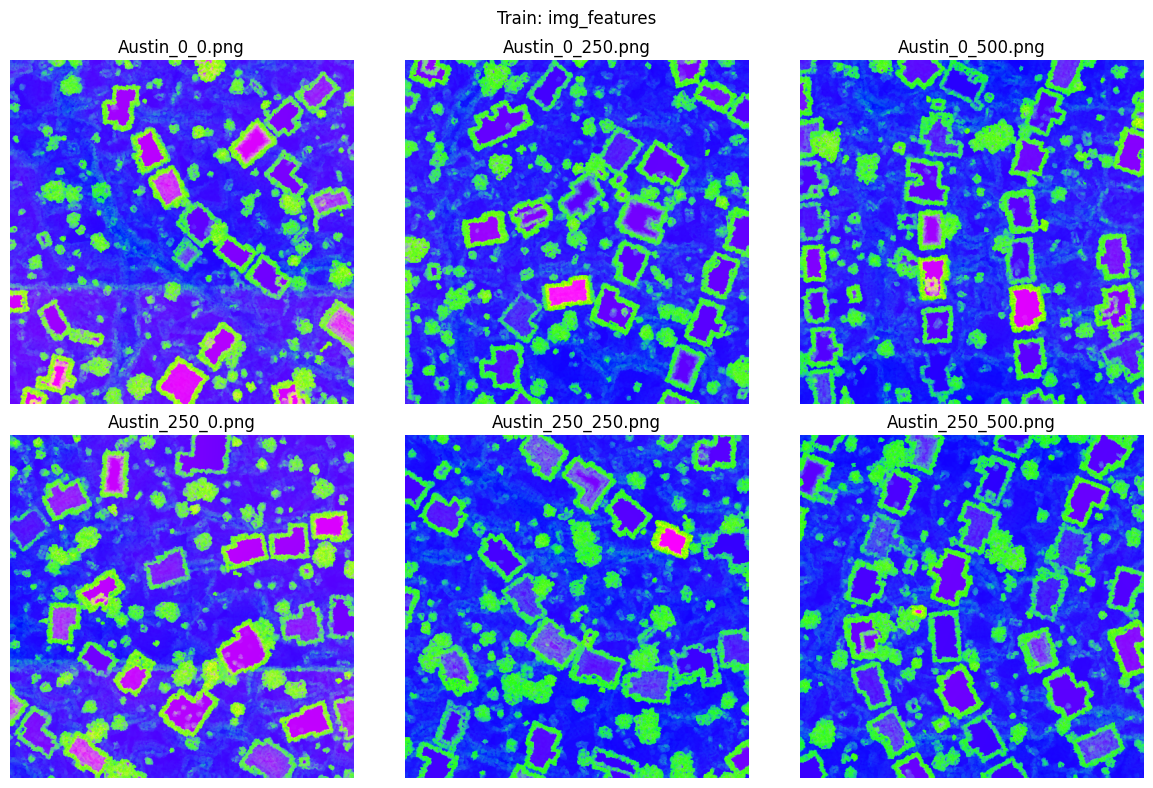

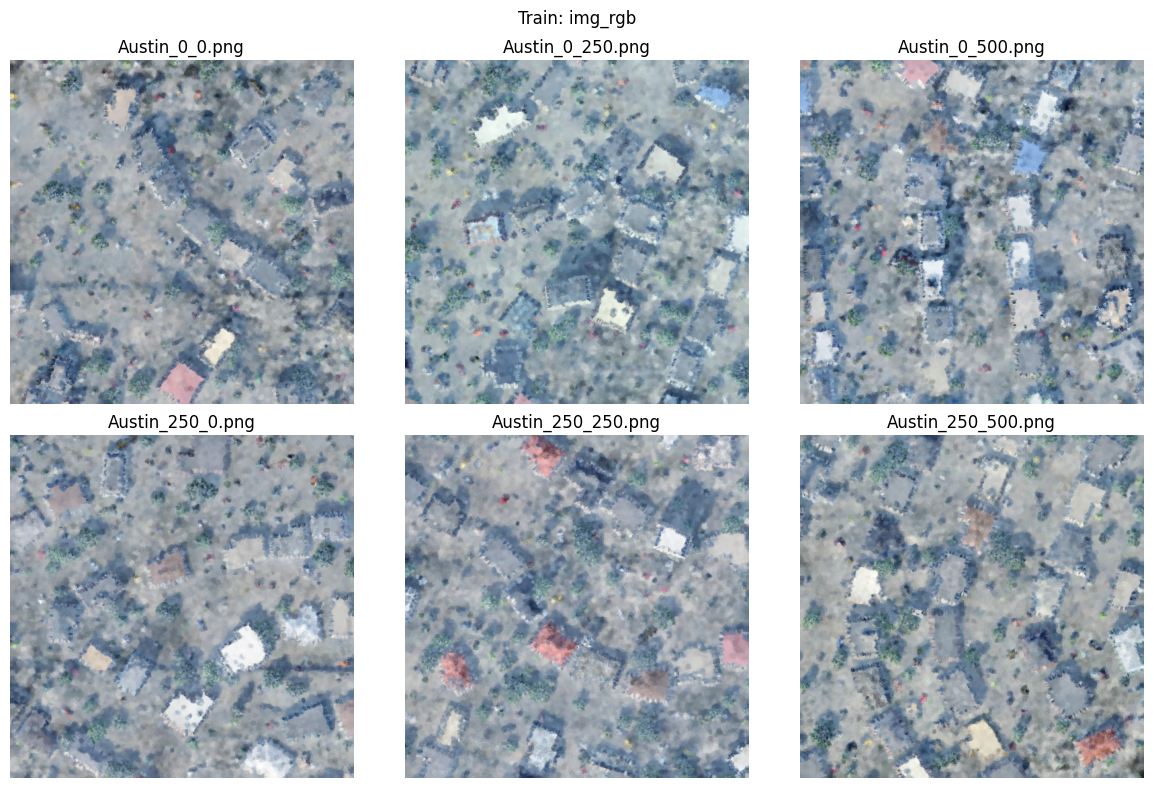

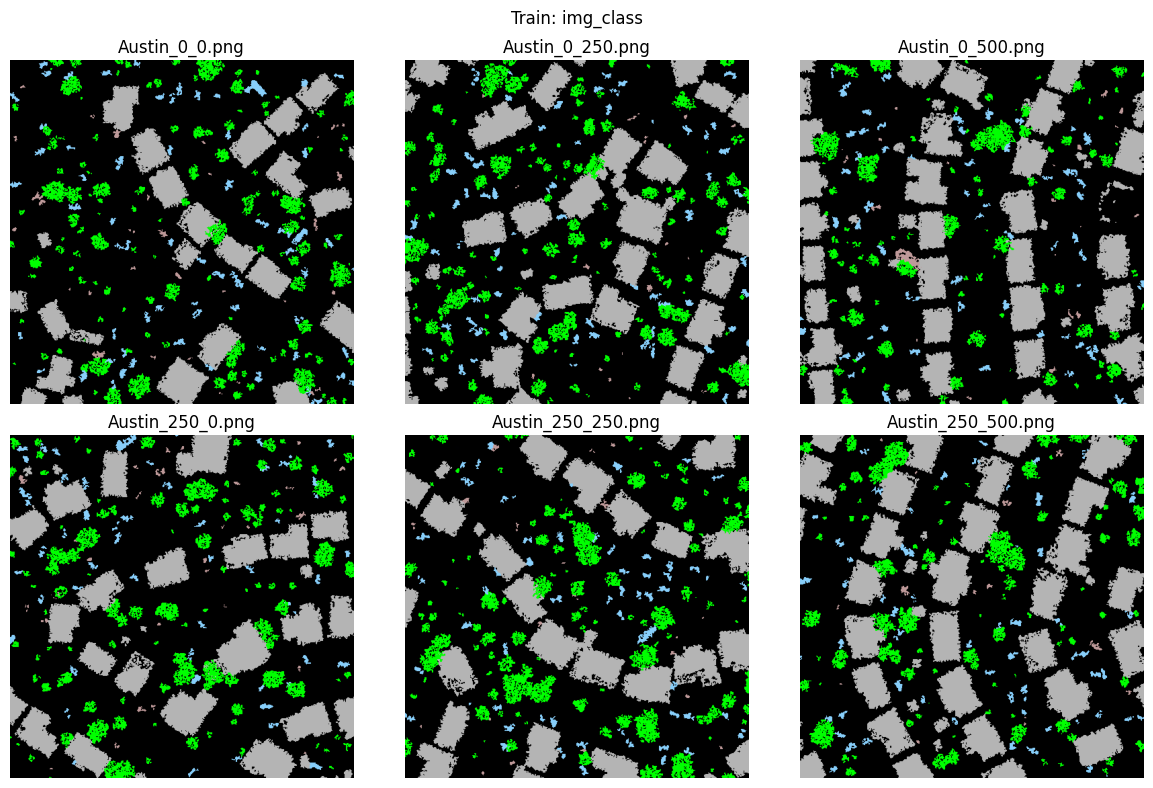

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image 

show_samples(CFG['ready_root'] / 'train' / 'img_features', 'Train: img_features')
show_samples(CFG['ready_root'] / 'train' / 'img_rgb', 'Train: img_rgb')
show_samples(CFG['ready_root'] / 'train' / 'img_class', 'Train: img_class')

In [12]:
!nvidia-smi

Mon Feb 16 18:28:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4) Train

In [15]:
import subprocess, sys
from pathlib import Path

PROJECT_ROOT = Path("/content/lidar-visual-interface")
train_py = PROJECT_ROOT / "training" / "train.py"

cmd = [
    sys.executable, str(train_py),
    "--features-dir", "/content/stpls3d_ready/train/img_features",
    "--masks-dir", "/content/stpls3d_ready/train/img_class",
    "--epochs", "2",
    "--batch-size", "2",
    "--lr", "0.001",
    "--device", "auto",
    "--checkpoint-dir", str(PROJECT_ROOT / "checkpoints_notebook"),
    "--seed", "42",
]

p = subprocess.run(cmd, cwd=str(PROJECT_ROOT), capture_output=True, text=True)
print("returncode:", p.returncode)
print("\nSTDOUT:\n", p.stdout)
print("\nSTDERR:\n", p.stderr)

returncode: 1

STDOUT:
 

STDERR:
 Traceback (most recent call last):
  File "/content/lidar-visual-interface/training/train.py", line 28, in <module>
    from musac_las_classifier.constants import CLASS_COLORS, CLASS_NAMES
ModuleNotFoundError: No module named 'musac_las_classifier'



In [23]:
import os, sys, subprocess
from pathlib import Path

PROJECT_ROOT = Path("/content/lidar-visual-interface")

# Делаем корень репо видимым для импортов
os.environ["PYTHONPATH"] = f"{PROJECT_ROOT}:{os.environ.get('PYTHONPATH','')}"

cmd = [
    sys.executable, "-m", "training.train",
    "--features-dir", "/content/stpls3d_ready/train/img_features",
    "--masks-dir", "/content/stpls3d_ready/train/img_class",
    "--epochs", "5",
    "--batch-size", "2",
    "--lr", "0.001",
    "--device", "auto",
    "--checkpoint-dir", str(PROJECT_ROOT / "checkpoints_notebook"),
    "--seed", "42",
]

subprocess.run(cmd, cwd=str(PROJECT_ROOT), check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'training.train', '--features-dir', '/content/stpls3d_ready/train/img_features', '--masks-dir', '/content/stpls3d_ready/train/img_class', '--epochs', '5', '--batch-size', '2', '--lr', '0.001', '--device', 'auto', '--checkpoint-dir', '/content/lidar-visual-interface/checkpoints_notebook', '--seed', '42'], returncode=0)

In [25]:
import os, sys, subprocess
from pathlib import Path

PROJECT_ROOT = Path("/content/lidar-visual-interface")
os.environ["PYTHONPATH"] = f"{PROJECT_ROOT}:{os.environ.get('PYTHONPATH','')}"

cmd = [
    sys.executable, "-u", "-m", "training.train",   # -u = unbuffered
    "--features-dir", "/content/stpls3d_ready/train/img_features",
    "--masks-dir", "/content/stpls3d_ready/train/img_class",
    "--epochs", "5",
    "--batch-size", "2",
    "--lr", "0.001",
    "--device", "auto",
    "--checkpoint-dir", str(PROJECT_ROOT / "checkpoints_notebook"),
    "--seed", "42",
]

with subprocess.Popen(
    cmd,
    cwd=str(PROJECT_ROOT),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
) as p:
    for line in p.stdout:
        print(line, end="")

print("returncode:", p.wait())

18:44:29 [INFO] Loading data: features=/content/stpls3d_ready/train/img_features, masks=/content/stpls3d_ready/train/img_class
18:44:29 [INFO] Train: 11 batches, Val: 3 batches
18:44:30 [INFO] Hardware info saved to /content/lidar-visual-interface/checkpoints_notebook/hardware_info.json
18:44:30 [INFO] Training config saved to /content/lidar-visual-interface/checkpoints_notebook/training_config.json
18:44:41 [INFO] New best model at epoch 1 (val mIoU: 0.0377)
18:44:41 [INFO] Epoch 1/5 — Train Loss: 0.2964, Val Loss: 0.3036, Train mIoU: 0.0310, Val mIoU: 0.0377, Time: 11.3s
18:44:52 [INFO] Epoch 2/5 — Train Loss: 0.2604, Val Loss: 0.3120, Train mIoU: 0.0296, Val mIoU: 0.0303, Time: 10.7s
18:45:03 [INFO] New best model at epoch 3 (val mIoU: 0.0613)
18:45:03 [INFO] Epoch 3/5 — Train Loss: 0.2244, Val Loss: 0.2707, Train mIoU: 0.0564, Val mIoU: 0.0613, Time: 11.0s
18:45:14 [INFO] Epoch 4/5 — Train Loss: 0.2235, Val Loss: 0.2890, Train mIoU: 0.0496, Val mIoU: 0.0460, Time: 11.0s
18:45:25 [I

In [22]:
import shlex

if RUN_TRAIN:
    run_cmd([
        sys.executable,
        '-m',
        'training.train',
        '--features-dir', CFG['ready_root'] / 'train' / 'img_features',
        '--masks-dir', CFG['ready_root'] / 'train' / 'img_class',
        '--epochs', CFG['epochs'],
        '--batch-size', CFG['batch_size'],
        '--lr', CFG['lr'],
        '--device', CFG['device'],
        '--checkpoint-dir', CFG['checkpoint_dir'],
        '--seed', CFG['seed'],
    ])
else:
    print('RUN_TRAIN=False -> skipped')

$ /usr/bin/python3 -m training.train --features-dir /content/stpls3d_ready/train/img_features --masks-dir /content/stpls3d_ready/train/img_class --epochs 2 --batch-size 2 --lr 0.001 --device auto --checkpoint-dir /content/lidar-visual-interface/checkpoints_notebook --seed 42


In [20]:
import os, sys, subprocess
from pathlib import Path

PROJECT_ROOT = Path("/content/lidar-visual-interface")
os.environ["PYTHONPATH"] = f"{PROJECT_ROOT}:{os.environ.get('PYTHONPATH','')}"

cmd = [
    sys.executable, "-m", "training.train",
    "--features-dir", "/content/stpls3d_ready/train/img_features",
    "--masks-dir", "/content/stpls3d_ready/train/img_class",
    "--epochs", "20",
    "--batch-size", "2",
    "--lr", "0.001",
    "--device", "auto",
    "--checkpoint-dir", str(PROJECT_ROOT / "checkpoints_notebook"),
    "--seed", "42",
]

p = subprocess.run(
    cmd,
    cwd=str(PROJECT_ROOT),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(p.stdout)         # весь лог обучения
print("returncode:", p.returncode)


KeyboardInterrupt: 

In [18]:
import subprocess, sys
from pathlib import Path

PROJECT_ROOT = Path("/content/lidar-visual-interface")

subprocess.run([
    sys.executable, "training/evaluate.py",
    "--checkpoint", str(PROJECT_ROOT / "checkpoints_notebook" / "best_model.pth"),
    "--features-dir", "/content/stpls3d_ready/test/img_features",
    "--masks-dir", "/content/stpls3d_ready/test/img_class",
    "--batch-size", "2",
    "--device", "auto",
    "--output-dir", str(PROJECT_ROOT / "eval_notebook_test"),
], cwd=str(PROJECT_ROOT), check=True)

CompletedProcess(args=['/usr/bin/python3', 'training/evaluate.py', '--checkpoint', '/content/lidar-visual-interface/checkpoints_notebook/best_model.pth', '--features-dir', '/content/stpls3d_ready/test/img_features', '--masks-dir', '/content/stpls3d_ready/test/img_class', '--batch-size', '2', '--device', 'auto', '--output-dir', '/content/lidar-visual-interface/eval_notebook_test'], returncode=0)

,epoch,train_loss,val_loss,train_miou,val_miou,epoch_time_sec
0,1,0.296399,0.303613,0.030956,0.037651,11.41
1,2,0.260351,0.311960,0.029560,0.030345,10.64
2,3,0.224433,0.270743,0.056445,0.061285,10.89
3,4,0.223545,0.289009,0.049590,0.045988,10.76
4,5,0.207001,0.314201,0.035532,0.023393,10.86


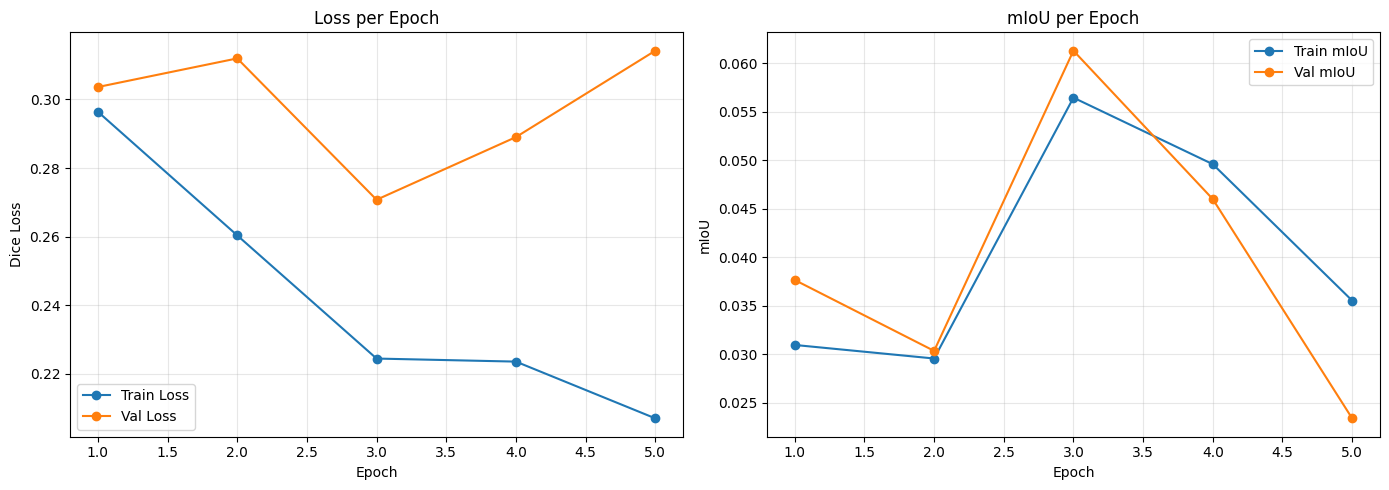

In [24]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ckpt_dir = Path("/content/lidar-visual-interface/checkpoints_notebook")
csv_path = ckpt_dir / "epoch_summary.csv"

assert csv_path.exists(), f"Not found: {csv_path}"
df = pd.read_csv(csv_path)
display(df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(df["epoch"], df["train_loss"], marker="o", label="Train Loss")
axes[0].plot(df["epoch"], df["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Dice Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

# mIoU
axes[1].plot(df["epoch"], df["train_miou"], marker="o", label="Train mIoU")
axes[1].plot(df["epoch"], df["val_miou"], marker="o", label="Val mIoU")
axes[1].set_title("mIoU per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mIoU")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:
!find  -maxdepth 5 -type f -name "train.py"

./training/train.py


In [13]:
cd lidar-visual-interface/

/content/lidar-visual-interface


In [14]:
!git switch feature/paper-arxiv-draft

Branch 'feature/paper-arxiv-draft' set up to track remote branch 'feature/paper-arxiv-draft' from 'origin'.
Switched to a new branch 'feature/paper-arxiv-draft'


In [42]:
import subprocess, shlex, sys

cmd = [
    sys.executable, "-m", "lidar-visual-interface.training.train",
    "--features-dir", "/content/stpls3d_ready/train/img_features",
    "--masks-dir", "/content/stpls3d_ready/train/img_class",
    "--epochs", "2",
    "--batch-size", "2",
    "--lr", "0.001",
    "--device", "auto",
    "--checkpoint-dir", "/content/lidar-visual-interface/checkpoints_notebook",
    "--seed", "42",
]

print("$", " ".join(shlex.quote(c) for c in cmd))
p = subprocess.run(cmd, cwd=str(PROJECT_ROOT), capture_output=True, text=True)
print("returncode:", p.returncode)
print("STDOUT:\n", p.stdout)
print("STDERR:\n", p.stderr)

$ /usr/bin/python3 -m lidar-visual-interface.training.train --features-dir /content/stpls3d_ready/train/img_features --masks-dir /content/stpls3d_ready/train/img_class --epochs 2 --batch-size 2 --lr 0.001 --device auto --checkpoint-dir /content/lidar-visual-interface/checkpoints_notebook --seed 42
returncode: 1
STDOUT:
 
STDERR:
 /usr/bin/python3: Error while finding module specification for 'lidar-visual-interface.training.train' (ModuleNotFoundError: No module named 'lidar-visual-interface')



In [40]:
run_cmd([
    sys.executable, "/content/lidar-visual-interface/training/train.py",
    "--features-dir", "/content/stpls3d_ready/train/img_features",
    "--masks-dir", "/content/stpls3d_ready/train/img_class",
    "--epochs", "2",
    "--batch-size", "2",
    "--lr", "0.001",
    "--device", "auto",
    "--checkpoint-dir", "/content/lidar-visual-interface/checkpoints_notebook",
    "--seed", "42",
], cwd=PROJECT_ROOT)

$ /usr/bin/python3 /content/lidar-visual-interface/training/train.py --features-dir /content/stpls3d_ready/train/img_features --masks-dir /content/stpls3d_ready/train/img_class --epochs 2 --batch-size 2 --lr 0.001 --device auto --checkpoint-dir /content/lidar-visual-interface/checkpoints_notebook --seed 42


RuntimeError: Command failed with exit code 2

In [44]:
from pathlib import Path
import os, sys, subprocess

PROJECT_ROOT = Path("/content/lidar-visual-interface")
print("exists:", PROJECT_ROOT.exists())
print("files:", [p.name for p in PROJECT_ROOT.iterdir()][:20])

# чтобы Python видел пакет из репо
os.environ["PYTHONPATH"] = str(PROJECT_ROOT) + ":" + os.environ.get("PYTHONPATH", "")

exists: True
files: ['requirements_polygon_app.txt', 'main_poligon_desktop.py', 'README.md', 'GENERAL_REPORT.md', 'main_color_las_st_tk.py', '.gitignore', 'utils.py', 'create_placeholder_images.py', 'generate_colored_las_3D', 'preprocessing', 'requirements.txt', 'postprocessing', 'main_color_las_tk.py', 'main_polygon_desktop_tk.py', 'main_poligon.py', 'main_color_las.py', 'requirements_3d_las_colored_app.txt', 'polygon_generator', 'report_images', '.git']


In [52]:
import subprocess, sys
from pathlib import Path

PROJECT_ROOT = Path("/content/lidar-visual-interface")

cmd = [
    sys.executable, '-m', "/content/lidar-visual-interface/training/train",
    "--features-dir", "/content/stpls3d_ready/train/img_features",
    "--masks-dir", "/content/stpls3d_ready/train/img_class",
    "--epochs", "2",
    "--batch-size", "2",
    "--lr", "0.001",
    "--device", "auto",
    "--checkpoint-dir", "/content/lidar-visual-interface/checkpoints_notebook",
    "--seed", "42",
]

p = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)
print("returncode:", p.returncode)
print("\nSTDOUT:\n", p.stdout)
print("\nSTDERR:\n", p.stderr)

returncode: 1

STDOUT:
 

STDERR:
 /usr/bin/python3: No module named /content/lidar-visual-interface/training/train



In [57]:
!python -m lidar-visual-interface/training/train.py

/usr/bin/python3: Error while finding module specification for 'lidar-visual-interface/training/train.py' (ModuleNotFoundError: No module named 'lidar-visual-interface/training/train'). Try using 'lidar-visual-interface/training/train' instead of 'lidar-visual-interface/training/train.py' as the module name.


In [48]:
!ls

archive.zip  las-filter  lidar-visual-interface  sample_data  stpls3d_ready


In [ ]:
epoch_summary = CFG['checkpoint_dir'] / 'epoch_summary.csv'
if epoch_summary.exists():
    df = pd.read_csv(epoch_summary)
    display(df.tail())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df['epoch'], df['train_loss'], label='train_loss')
    axes[0].plot(df['epoch'], df['val_loss'], label='val_loss')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(df['epoch'], df['train_miou'], label='train_miou')
    axes[1].plot(df['epoch'], df['val_miou'], label='val_miou')
    axes[1].set_title('mIoU')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print('No epoch_summary.csv yet:', epoch_summary)

## 5) Evaluate on VAL and TEST

In [ ]:
best_ckpt = CFG['checkpoint_dir'] / 'best_model.pth'
print('best_ckpt =', best_ckpt)

if RUN_EVAL:
    run_cmd([
        sys.executable,
        'training/evaluate.py',
        '--checkpoint', best_ckpt,
        '--features-dir', CFG['ready_root'] / 'val' / 'img_features',
        '--masks-dir', CFG['ready_root'] / 'val' / 'img_class',
        '--batch-size', CFG['batch_size'],
        '--device', CFG['device'],
        '--seed', CFG['seed'],
        '--output-dir', CFG['eval_val_dir'],
    ])

    run_cmd([
        sys.executable,
        'training/evaluate.py',
        '--checkpoint', best_ckpt,
        '--features-dir', CFG['ready_root'] / 'test' / 'img_features',
        '--masks-dir', CFG['ready_root'] / 'test' / 'img_class',
        '--batch-size', CFG['batch_size'],
        '--device', CFG['device'],
        '--seed', CFG['seed'],
        '--output-dir', CFG['eval_test_dir'],
    ])
else:
    print('RUN_EVAL=False -> skipped')

In [ ]:
for name, path in [('VAL', CFG['eval_val_dir']), ('TEST', CFG['eval_test_dir'])]:
    summary_path = path / 'evaluation_summary.json'
    metrics_path = path / 'evaluation_metrics.csv'
    print(f'\
[{name}] {path}')
    if summary_path.exists():
        summary = json.loads(summary_path.read_text(encoding='utf-8'))
        print('  mIoU:', summary.get('miou'))
        print('  val_loss:', summary.get('val_loss'))
    else:
        print('  No summary yet.')

    if metrics_path.exists():
        dfm = pd.read_csv(metrics_path)
        display(dfm.head(10))
    else:
        print('  No metrics CSV yet.')